In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import anndata as ad
import torch
import pytorch_lightning as pl
from scdiff.dataset import ScDataModule
from scdiff.ae import LightningAE
import scanpy as sc
import os
from scdiff.plot import compare_umap, umap_plot
from scdiff.transform import NormalLog1pScaler

In [5]:
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')
muris

AnnData object with n_obs × n_vars = 57004 × 18996
    obs: 'celltype', 'n_genes', 'counts'
    var: 'n_cells'

In [ ]:
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)
sc.pp.normalize_total(muris, target_sum=1e4)
sc.pp.log1p(muris)

In [7]:
muris.obs

,celltype,n_genes,counts
AAACCTGAGCATCATC-1,Marrow,3470,12996.0
AAACCTGCAGAGTGTG-1,Marrow,1764,5437.0
AAACCTGGTCGAACAG-1,Marrow,1526,4466.0
AAACCTGTCACTTCAT-1,Marrow,4044,23853.0
AAACGGGAGAAGGTTT-1,Marrow,977,4375.0
...,...,...,...
736877,Trachea,2256,6507.0
736941,Trachea,772,1672.0
737147,Trachea,1302,2589.0
737253,Trachea,973,2373.0


In [8]:
murisData = ScDataModule(muris, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=muris.X.shape[1])

log_dir = "lightning_logs/muris/ae"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

trainer = pl.Trainer(
    max_epochs=50, # may need more training
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir=log_dir
)

ae_path = "checkpoints/muris/trained_ae.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, murisData)
    trainer.save_checkpoint(ae_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [9]:
device = next(ae.parameters()).device
X_tensor = torch.tensor(muris.X.toarray(), dtype=torch.float32, device=device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()   

encoded_muris = ad.AnnData(X_encoded, obs=muris.obs.copy())

In [10]:
# umap_plot(X_encoded, muris.obs["celltype"])

In [11]:
# sc.pp.neighbors(encoded_muris, n_neighbors=10, n_pcs=20)
# sc.tl.umap(encoded_muris)
# sc.pl.umap(encoded_muris, color="celltype", title="UMAP of encoded muris")

In [12]:
from sklearn.preprocessing import StandardScaler
from scdiff.lightning_diffusion import LightningDiffusion   

standard_scaler = StandardScaler()
scaled_X_encoded = standard_scaler.fit_transform(X_encoded)
encoded_muris.X = scaled_X_encoded
latent_dm = ScDataModule(encoded_muris, label_key="celltype", 
                        encoder="LabelEncoder", batch_size=128, val_split=0.1, balanced_sampling=True)
latent_dm.setup()

dim = scaled_X_encoded.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999,
)

trainer = pl.Trainer(
    max_epochs=150,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/muris/diffusion"
)

diffusion_model_path = "checkpoints/muris/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(num_samples=10000,
                                    sampling_timesteps=100,
                                    ddim_sampling_eta=0.0,
                                    use_ema=True,
                                    clip_denoised=False)

DDIM sampling: 100%|██████████| 100/100 [00:59<00:00,  1.69it/s]


In [19]:
latent_samples = standard_scaler.inverse_transform(latent_samples.detach())
decoded_samples = ae.decode(torch.tensor(latent_samples, dtype=torch.float32, device=device))

In [14]:
import numpy as np
samples_baseline = np.load('../data/comparisons/sim_muris_decoded.npy')    
samples_baseline.shape 

(10000, 18996)

In [20]:
decoded_samples = decoded_samples.detach().cpu().numpy()
decoded_samples

array([[ -63.70805  ,   11.205289 ,  294.1668   , ...,  -25.669952 ,
          10.883487 ,  164.97696  ],
       [-302.6189   ,  175.5929   ,  384.7971   , ..., -372.8084   ,
          83.51563  ,  808.15283  ],
       [-105.32019  ,   82.167015 ,  154.7851   , ..., -117.72097  ,
          29.629011 ,   97.101006 ],
       ...,
       [-518.08466  ,  254.34149  , -143.66359  , ..., -468.35077  ,
         221.571    ,  477.76636  ],
       [ -73.543724 ,   43.41244  ,  -10.942756 , ..., -104.06143  ,
          -1.5847504,  127.774414 ],
       [-193.53433  ,   84.3819   ,  -71.98462  , ..., -191.28268  ,
         134.42134  ,   -5.2167425]], shape=(10000, 18996), dtype=float32)

Performing UMAP on combined dataset (20000 samples, 18996 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[-0.96555763, 12.159408  ],
         [-7.741254  , -6.4619904 ],
         [-2.147646  ,  0.56634486],
         ...,
         [-1.9604886 , 12.071743  ],
         [-7.861346  , -6.8405995 ],
         [-7.37403   , -6.125017  ]], shape=(10000, 2), dtype=float32),
  array([[13.596076  , -0.72111523],
         [12.64263   , -0.77400005],
         [15.758782  , -1.207198  ],
         ...,
         [16.858467  ,  0.4651037 ],
         [15.661158  , -2.410793  ],
         [14.268022  , -2.3536806 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

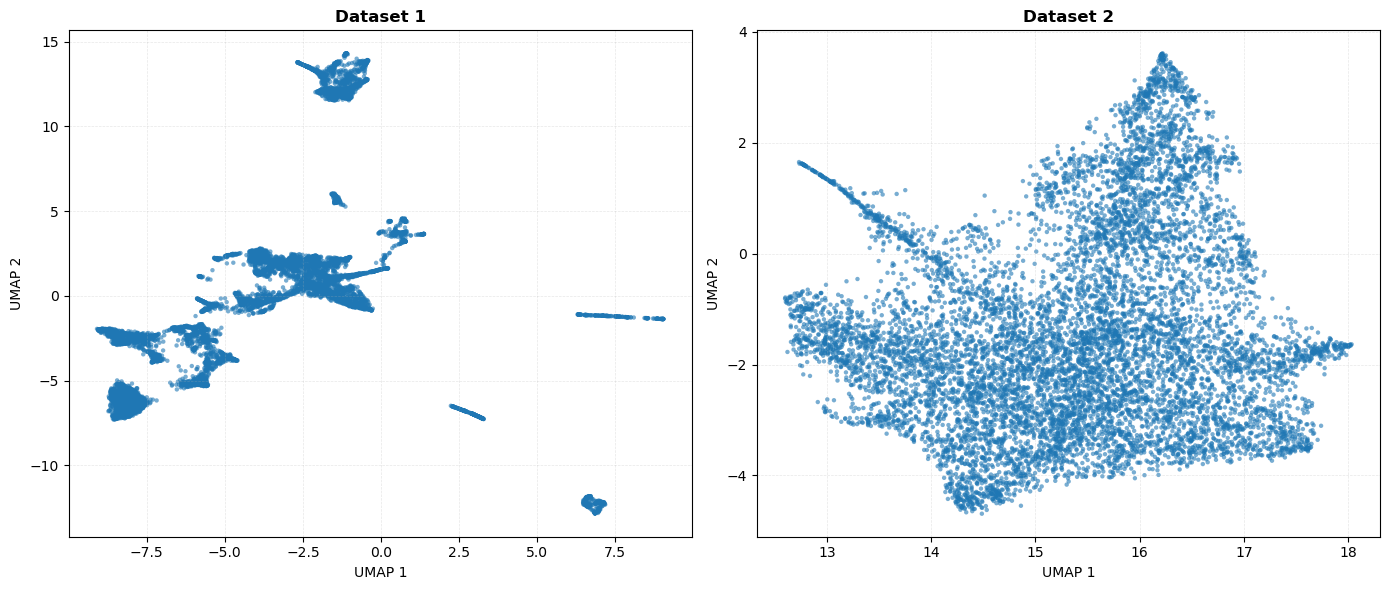

In [21]:
muris_10k = muris.X.toarray()[np.random.choice(muris.n_obs, 10000, replace=False)]
compare_umap([muris_10k, decoded_samples])

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[-2.019499 ,  3.6672885],
         [ 1.7721633,  5.0492887],
         [12.134286 ,  7.148781 ],
         ...,
         [ 2.100122 ,  2.2132978],
         [-3.3966224,  7.0801682],
         [ 6.239841 , 10.019514 ]], shape=(10000, 2), dtype=float32),
  array([[ 7.07744  , 13.120699 ],
         [ 7.724871 , 12.664867 ],
         [ 4.7348385,  9.996753 ],
         ...,
         [ 7.971084 , 10.59431  ],
         [ 7.9698763, 12.479894 ],
         [ 5.9277596, 12.841082 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

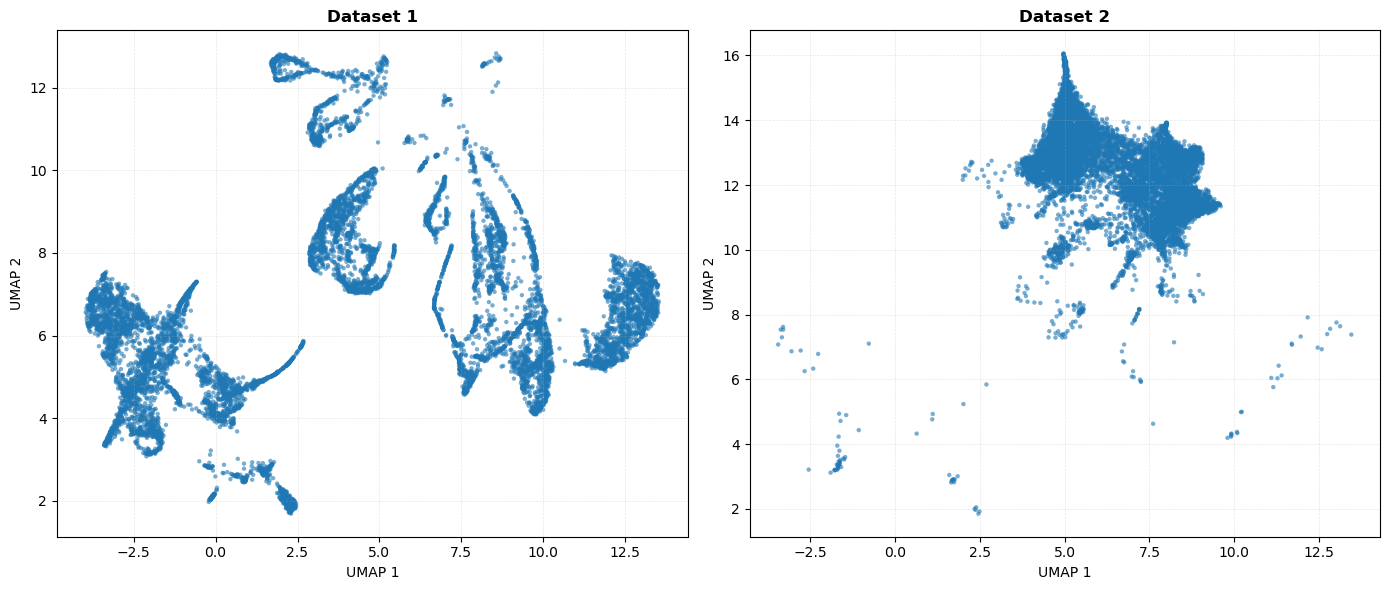

In [23]:
compare_umap([X_encoded[np.random.choice(X_encoded.shape[0], 10000, replace=False)], 
              latent_samples])

Performing UMAP on combined dataset (20000 samples, 18996 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[-6.2157755, -4.2770452],
         [-9.733019 ,  4.0538507],
         [-4.2981024, 11.228126 ],
         ...,
         [-7.125441 , -4.4043565],
         [-9.930464 ,  4.313682 ],
         [-9.717286 ,  3.772655 ]], shape=(10000, 2), dtype=float32),
  array([[16.62906  ,  6.3348856],
         [19.583578 , 15.984685 ],
         [11.139101 , 14.282054 ],
         ...,
         [18.542498 , 15.023933 ],
         [11.686131 , 14.757253 ],
         [15.214395 , 16.360102 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

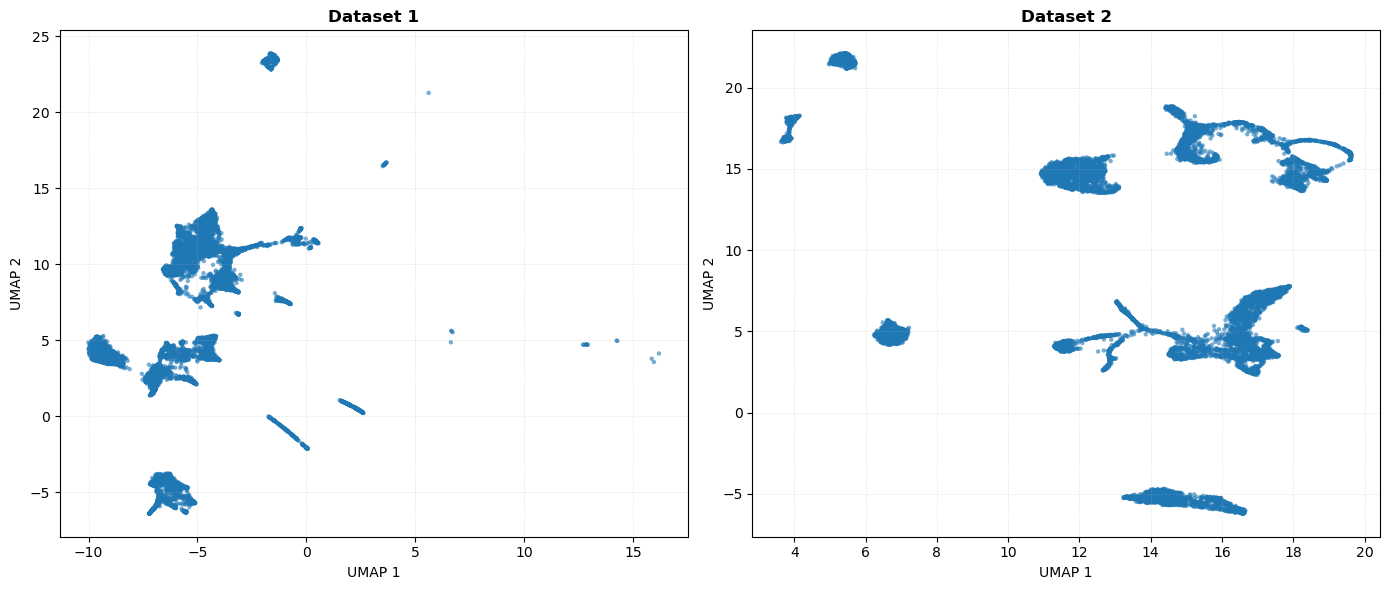

In [22]:
compare_umap([muris_10k, samples_baseline])